# PM2.5 Prediction from VAE Latent Space (latent6_pm25wt)

Same analysis as latent6_nodoy but using the PM2.5-weighted VAE. Includes per-component RF.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

os.chdir('/home/vcaristo/pm_data/vae/runs/latent6_pm25wt')

df = pd.read_parquet('/home/vcaristo/pm_data/svgp/full_conus/loso_temp_data.parquet')
emb = np.load('embeddings.npz')
Z_mu = emb['z_mu']
assignments = emb['assignments']
y = np.log(df['pm25'].values + 1)

time_varying = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']
raw_cols = [f for f in time_varying if f in df.columns] + [f for f in static if f in df.columns]
X_raw = df[raw_cols].values

idx_train, idx_test = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]

np.random.seed(42)
n_sub = 200_000
sub_train = np.random.choice(idx_train, n_sub, replace=False)
sub_test = np.random.choice(idx_test, n_sub // 4, replace=False)

scaler = StandardScaler()
X_raw_s = scaler.fit_transform(X_raw)

results = {}
print(f"Z_mu: {Z_mu.shape}, Train: {len(idx_train):,}, Test: {len(idx_test):,}")

Z_mu: (1883144, 6), Train: 1,506,515, Test: 376,629


## Single-model baselines

In [2]:
# LR on latent
lr = LinearRegression().fit(Z_mu[idx_train], y_train)
results['LR (6D latent)'] = {'r2': r2_score(y_test, lr.predict(Z_mu[idx_test])),
    'rmse': np.sqrt(mean_squared_error(y_test, lr.predict(Z_mu[idx_test]))), 'n_features': 6}

# LR on raw
X_tr_s = StandardScaler().fit_transform(X_raw[idx_train])
X_te_s = StandardScaler().fit(X_raw[idx_train]).transform(X_raw[idx_test])
lr_raw = LinearRegression().fit(X_tr_s, y_train)
results['LR (16 raw)'] = {'r2': r2_score(y_test, lr_raw.predict(X_te_s)),
    'rmse': np.sqrt(mean_squared_error(y_test, lr_raw.predict(X_te_s))), 'n_features': 16}

# RF on latent
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(Z_mu[sub_train], y[sub_train])
pred_rf = rf.predict(Z_mu[sub_test])
results['RF (6D latent)'] = {'r2': r2_score(y[sub_test], pred_rf),
    'rmse': np.sqrt(mean_squared_error(y[sub_test], pred_rf)), 'n_features': 6}

# RF on raw
rf_raw = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_raw.fit(X_raw_s[sub_train], y[sub_train])
pred_rf_raw = rf_raw.predict(X_raw_s[sub_test])
results['RF (16 raw)'] = {'r2': r2_score(y[sub_test], pred_rf_raw),
    'rmse': np.sqrt(mean_squared_error(y[sub_test], pred_rf_raw)), 'n_features': 16}

print(f"{'Model':<30} {'R²':>8} {'RMSE':>8}")
print("-" * 50)
for name, r in results.items():
    print(f"{name:<30} {r['r2']:>8.4f} {r['rmse']:>8.4f}")

Model                                R²     RMSE
--------------------------------------------------
LR (6D latent)                   0.2392   0.5926
LR (16 raw)                      0.3143   0.5625
RF (6D latent)                   0.4748   0.4933
RF (16 raw)                      0.5400   0.4617


## Per-component random forests

In [3]:
K = len(np.unique(assignments))
pred_per_comp_latent = np.full(len(sub_test), np.nan)
pred_per_comp_raw = np.full(len(sub_test), np.nan)
comp_results = []

for k in range(K):
    train_mask = assignments[sub_train] == k
    test_mask = assignments[sub_test] == k
    n_tr, n_te = train_mask.sum(), test_mask.sum()
    
    if n_tr < 50 or n_te < 10:
        print(f"  Component {k}: skipped (n_train={n_tr}, n_test={n_te})")
        continue
    
    rf_k = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    rf_k.fit(Z_mu[sub_train[train_mask]], y[sub_train[train_mask]])
    pred_per_comp_latent[test_mask] = rf_k.predict(Z_mu[sub_test[test_mask]])
    
    rf_k_raw = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    rf_k_raw.fit(X_raw_s[sub_train[train_mask]], y[sub_train[train_mask]])
    pred_per_comp_raw[test_mask] = rf_k_raw.predict(X_raw_s[sub_test[test_mask]])
    
    r2_k_latent = r2_score(y[sub_test[test_mask]], pred_per_comp_latent[test_mask])
    r2_k_raw = r2_score(y[sub_test[test_mask]], pred_per_comp_raw[test_mask])
    
    comp_results.append({'component': k, 'n_train': n_tr, 'n_test': n_te,
                         'r2_latent': r2_k_latent, 'r2_raw': r2_k_raw})
    print(f"  Component {k}: n_train={n_tr:>6,} n_test={n_te:>5,} | "
          f"R²_latent={r2_k_latent:.4f}  R²_raw={r2_k_raw:.4f}")

valid = ~np.isnan(pred_per_comp_latent)
overall_r2_latent = r2_score(y[sub_test[valid]], pred_per_comp_latent[valid])
overall_r2_raw = r2_score(y[sub_test[valid]], pred_per_comp_raw[valid])

results['RF per-comp (6D latent)'] = {
    'r2': overall_r2_latent,
    'rmse': np.sqrt(mean_squared_error(y[sub_test[valid]], pred_per_comp_latent[valid])),
    'n_features': 6}
results['RF per-comp (16 raw)'] = {
    'r2': overall_r2_raw,
    'rmse': np.sqrt(mean_squared_error(y[sub_test[valid]], pred_per_comp_raw[valid])),
    'n_features': 16}

print(f"\nOverall R² (per-component RF):")
print(f"  Latent 6D:    {overall_r2_latent:.4f}")
print(f"  Raw 16 feat:  {overall_r2_raw:.4f}")
print(f"  (vs single RF latent: {results['RF (6D latent)']['r2']:.4f}, single RF raw: {results['RF (16 raw)']['r2']:.4f})")

  Component 0: n_train= 8,713 n_test=2,169 | R²_latent=0.4009  R²_raw=0.4430


  Component 1: n_train=19,474 n_test=4,888 | R²_latent=0.3363  R²_raw=0.4353


  Component 2: n_train= 9,353 n_test=2,338 | R²_latent=0.2441  R²_raw=0.3234


  Component 3: n_train=51,042 n_test=12,630 | R²_latent=0.3567  R²_raw=0.4606


  Component 4: n_train=14,102 n_test=3,520 | R²_latent=0.4003  R²_raw=0.4811


  Component 5: n_train=18,163 n_test=4,523 | R²_latent=0.2244  R²_raw=0.3922


  Component 6: n_train=33,383 n_test=8,331 | R²_latent=0.3483  R²_raw=0.4403


  Component 7: n_train=15,657 n_test=4,005 | R²_latent=0.4685  R²_raw=0.5490


  Component 8: n_train=12,059 n_test=3,125 | R²_latent=0.4906  R²_raw=0.5497


  Component 9: n_train=18,054 n_test=4,471 | R²_latent=0.4903  R²_raw=0.5659

Overall R² (per-component RF):
  Latent 6D:    0.4840
  Raw 16 feat:  0.5611
  (vs single RF latent: 0.4748, single RF raw: 0.5400)


## Summary

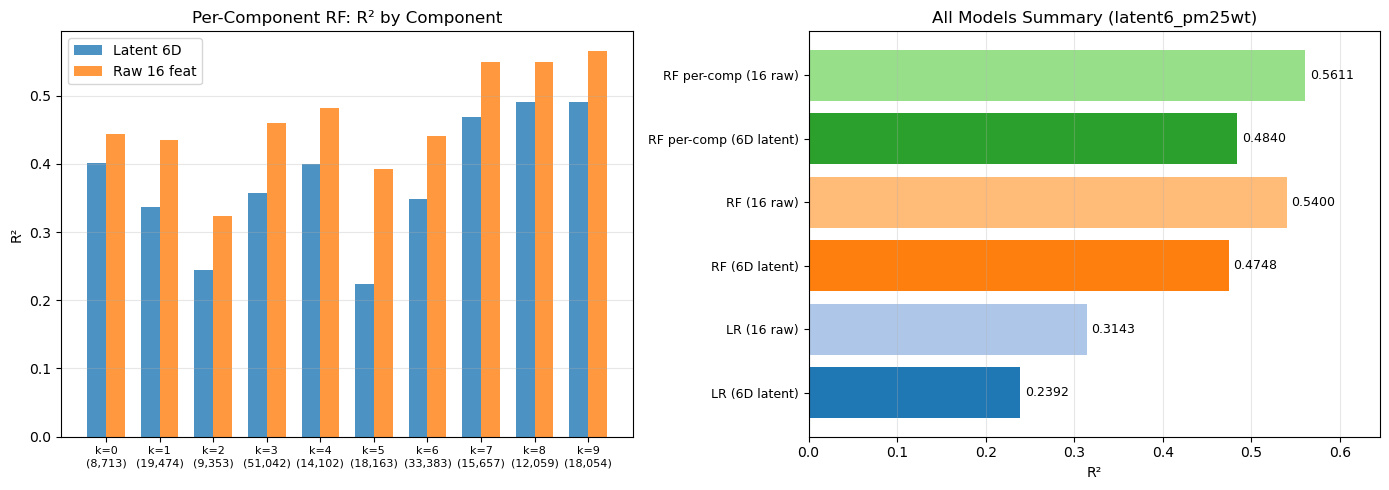

In [4]:
comp_df = pd.DataFrame(comp_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(comp_df))
width = 0.35
ax.bar(x_pos - width/2, comp_df['r2_latent'], width, label='Latent 6D', alpha=0.8)
ax.bar(x_pos + width/2, comp_df['r2_raw'], width, label='Raw 16 feat', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"k={k}\n({n:,})" for k, n in zip(comp_df['component'], comp_df['n_train'])], fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Per-Component RF: R² by Component')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
model_names = list(results.keys())
r2_vals = [results[m]['r2'] for m in model_names]
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a']
ax.barh(range(len(model_names)), r2_vals, color=colors[:len(model_names)])
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=9)
ax.set_xlabel('R²')
ax.set_title('All Models Summary (latent6_pm25wt)')
for i, v in enumerate(r2_vals):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlim(0, max(r2_vals) * 1.15)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/per_component_rf.png', dpi=150, bbox_inches='tight')
plt.show()